<a href="https://colab.research.google.com/github/Vatmuri2/backtest_setup/blob/main/Go1JumpCirriculumLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
    os.makedirs(os.path.dirname(NVIDIA_ICD_CONFIG_PATH), exist_ok=True)
    with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
        f.write('{\n  "file_format_version" : "1.0.0",\n  "ICD" : {\n    "library_path" : "libEGL_nvidia.so.0"\n  }\n}')
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 150.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 12.2 MB/s eta 0:00:00


In [2]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


In [3]:
# @title Import packages for plotting and creating graphics
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy:")
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [4]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [6]:
#@title Install MuJoCo Playground
!pip install playground

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 135.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.7/138.7 MB 16.5 MB/s eta 0:00:00


In [7]:
# Force install an earlier, potentially more compatible version of warp-lang
!pip install warp-lang==1.12.0 --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 122.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: warp-lang
    Found existing installation: warp-lang 1.14.0
    Uninstalling warp-lang-1.14.0:
      Successfully uninstalled warp-lang-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [5]:
#@title Import The Playground

from mujoco_playground import wrapper
from mujoco_playground import registry

In [6]:
registry.locomotion.ALL_ENVS

('ApolloJoystickFlatTerrain',
 'BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain')

In [7]:
env_name = 'Go1JoystickFlatTerrain'
env_cfg = registry.get_default_config(env_name)
env_cfg.impl = 'jax'
env = registry.load(env_name, config=env_cfg)

mujoco_menagerie not found. Downloading...


Cloning mujoco_menagerie: ██████████| 100/100 [00:39<00:00]


Checking out commit 1b86ece576591213e2b666ebf59508454200ca97
Successfully downloaded mujoco_menagerie


In [8]:
env_cfg = registry.get_default_config(env_name)
env_cfg.impl = 'jax'

import copy
base_cfg = copy.deepcopy(env_cfg)


In [9]:
OBSTACLE_X      = 2.0   # metres ahead of spawn
OBSTACLE_HALF_Y = 5.0   # spans full Y axis
OBSTACLE_HALF_X = 0.05  # 10 cm thick in X
INIT_HEIGHT     = 0.02  # 2 cm to start

In [30]:
import pathlib, re

xml_path = pathlib.Path(env._xml_path)
xml_dir  = xml_path.parent
base_xml = xml_path.read_text()

MESH_DIR = '/usr/local/lib/python3.12/dist-packages/mujoco_playground/external_deps/mujoco_menagerie/unitree_go1/assets'

obstacle_geom = (
    f'    <geom name="obstacle"\n'
    f'          type="box"\n'
    f'          size="{OBSTACLE_HALF_X} {OBSTACLE_HALF_Y} {INIT_HEIGHT/2:.4f}"\n'
    f'          pos="{OBSTACLE_X} 0 {INIT_HEIGHT/2:.4f}"\n'
    f'          rgba="0.85 0.33 0.10 1"\n'
    f'          contype="1" conaffinity="1"\n'
    f'          friction="0.8 0.1 0.1"/>\n'
)

# Read the full XML including all included files, resolve includes manually
def resolve_includes(xml_text, base_dir):
    """Recursively inline all <include file="..."/> tags."""
    def replacer(m):
        inc_path = base_dir / m.group(1)
        inc_text = inc_path.read_text()
        # Strip <?xml...?> and <mujoco>...</mujoco> wrapper if present
        inc_text = re.sub(r'<\?xml[^?]*\?>', '', inc_text)
        inc_text = re.sub(r'<mujoco[^>]*>', '', inc_text)
        inc_text = re.sub(r'</mujoco>', '', inc_text)
        return resolve_includes(inc_text, inc_path.parent)
    return re.sub(r'<include\s+file=["\\]([^"\\]+)["\\][^/]*/>', replacer, xml_text)

inlined = resolve_includes(base_xml, xml_dir)

# Now patch ALL meshdir occurrences to the absolute assets path
patched = re.sub(r'meshdir=["\\][^"\\]*["\\]', f'meshdir="{MESH_DIR}"', inlined)
if 'meshdir' not in patched:
    patched = re.sub(r'(<compiler\b)', f'\\1 meshdir="{MESH_DIR}"', patched)

# NEW PATCHING: Fix mesh file paths to use only the filename, relying on meshdir
def replace_mesh_file_paths(xml_text):
    """Replaces relative mesh file paths with just the filename."""
    def replacer(match):
        original_file_path = match.group(1)
        # Extract just the filename
        filename = pathlib.Path(original_file_path).name
        return f'file="{filename}"'
    # This regex targets .stl files referenced in <mesh> tags
    return re.sub(r'file=["\\]([^"\\]+\.stl)["\\]', replacer, xml_text)

patched = replace_mesh_file_paths(patched)

# Inject obstacle
assert "</worldbody>" in patched
obstacle_xml = patched.replace("</worldbody>", obstacle_geom + "\n</worldbody>", 1)

PATCHED_XML_PATH = xml_dir / "go1_obstacle_jump.xml"
PATCHED_XML_PATH.write_text(obstacle_xml)
print("Written to:", PATCHED_XML_PATH)
print("meshdir occurrences:", obstacle_xml.count(MESH_DIR))

Written to: /usr/local/lib/python3.12/dist-packages/mujoco_playground/_src/locomotion/go1/xmls/go1_obstacle_jump.xml
meshdir occurrences: 1


In [31]:
mj_model_obs = mujoco.MjModel.from_xml_path(str(PATCHED_XML_PATH))
mj_data_obs  = mujoco.MjData(mj_model_obs)

OBSTACLE_GEOM_ID = mujoco.mj_name2id(
    mj_model_obs, mujoco.mjtObj.mjOBJ_GEOM, "obstacle")
print(f"obstacle geom id = {OBSTACLE_GEOM_ID}")

mjx_model_obs = mjx.put_model(mj_model_obs)
print(f"MJX compiled. ngeom={mj_model_obs.ngeom} nu={mj_model_obs.nu}")

obstacle geom id = 0
MJX compiled. ngeom=52 nu=12


Scene with obstacle h=2cm

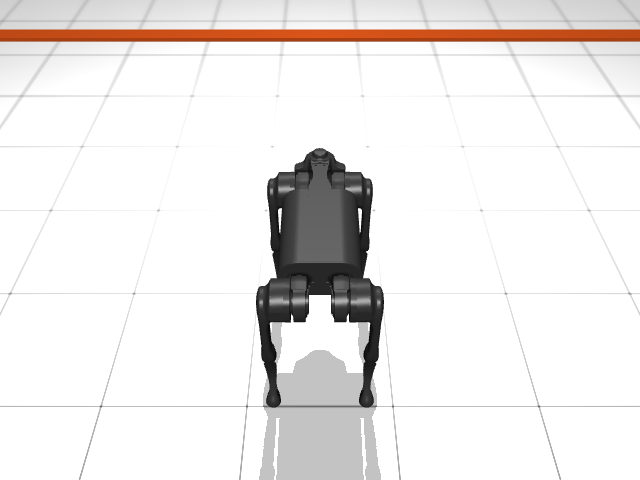

In [36]:
renderer = mujoco.Renderer(mj_model_obs, height=480, width=640)
mujoco.mj_forward(mj_model_obs, mj_data_obs)
renderer.update_scene(mj_data_obs, camera=1) # Use default camera at index 0
media.show_image(renderer.render(), title="Scene with obstacle h=2cm")

In [37]:
obs_cfg = copy.deepcopy(base_cfg)
obs_cfg.obstacle_height = INIT_HEIGHT
obs_cfg.obstacle_x      = OBSTACLE_X
obs_cfg.obstacle_half_x = OBSTACLE_HALF_X

if not hasattr(obs_cfg, "reward_config"):
    obs_cfg.reward_config = config_dict.ConfigDict()
if not hasattr(obs_cfg.reward_config, "scales"):
    obs_cfg.reward_config.scales = config_dict.ConfigDict()

obs_cfg.reward_config.scales.obstacle_cleared =  5.0
obs_cfg.reward_config.scales.forward_progress =  0.5
obs_cfg.reward_config.scales.obstacle_contact = -2.0
print("Config ready.")

Config ready.


In [101]:
from mujoco_playground._src.locomotion.go1 import base as go1_base
from mujoco_playground._src.locomotion.go1 import go1_constants as consts
from mujoco_playground._src import mjx_env
from mujoco.mjx._src import math as mjx_math


class Go1ObstacleJump(go1_base.Go1Env):

    def __init__(self, mj_model, mjx_model, obstacle_geom_id, config):
        self._mj_model         = mj_model
        self._mjx_model        = mjx_model
        self._config           = config
        self._obstacle_geom_id = obstacle_geom_id

        self._init_q       = jp.array(mj_model.keyframe("home").qpos)
        self._default_pose = jp.array(mj_model.keyframe("home").qpos[7:])

        lowers, uppers = mj_model.jnt_range[1:].T
        c = (lowers + uppers) / 2
        r = uppers - lowers
        self._soft_lowers = c - 0.5 * r * 0.9
        self._soft_uppers = c + 0.5 * r * 0.9

    def set_obstacle_height(self, height):
        half_z = height / 2.0
        cfg    = self._config
        g_size = np.array(self._mjx_model.geom_size)
        g_pos  = np.array(self._mjx_model.geom_pos)
        g_size[self._obstacle_geom_id] = [cfg.obstacle_half_x, 5.0, half_z]
        g_pos [self._obstacle_geom_id] = [cfg.obstacle_x, 0.0, half_z]
        object.__setattr__(self._mjx_model, "geom_size", jp.array(g_size))
        object.__setattr__(self._mjx_model, "geom_pos",  jp.array(g_pos))
        self._config.obstacle_height = height
        print(f"  Obstacle height = {height*100:.1f} cm")

    def reset(self, rng):
        rng, k1, k2 = jax.random.split(rng, 3)

        spawn_x = self._config.obstacle_x - jax.random.uniform(k1, (), minval=1.0, maxval=2.0)
        qpos    = self._init_q.at[0].set(spawn_x)

        yaw  = jax.random.uniform(k2, (1,), minval=-0.15, maxval=0.15)
        quat = mjx_math.axis_angle_to_quat(jp.array([0., 0., 1.]), yaw)
        qpos = qpos.at[3:7].set(mjx_math.quat_mul(qpos[3:7], quat))
        qvel = jp.zeros(self._mjx_model.nv).at[0].set(0.8)

        data = mjx_env.make_data(self._mjx_model)
        data = data.replace(qpos=qpos, qvel=qvel, ctrl=qpos[7:])
        data = mjx.forward(self._mjx_model, data)

        info = {
            "step":             jp.zeros((), dtype=jp.int32),
            "last_act":         jp.zeros(self._mjx_model.nu),
            "obstacle_cleared": jp.zeros((), dtype=jp.bool_),
            "command":          jp.array([1.0, 0.0, 0.0]),
        }
        metrics = {
            "reward/obstacle_cleared": jp.zeros(()),
            "reward/forward_progress": jp.zeros(()),
            "reward/obstacle_contact": jp.zeros(()),
            "curriculum/height_cm":    jp.array(self._config.obstacle_height * 100.),
            "reward": jp.zeros(()),
        }
        obs = self._get_obs(data, info)
        return mjx_env.State(data, obs, jp.zeros(()), jp.zeros(()), metrics, info)

    def step(self, state, action):
      cfg     = self._config
      targets = self._default_pose + action * getattr(cfg, "action_scale", 0.3)
      targets = jp.clip(targets, self._soft_lowers, self._soft_uppers)
      data    = mjx_env.step(self._mjx_model, state.data, targets,
                            getattr(cfg, "n_substeps", 5))
      obs     = self._get_obs(data, state.info)
      done    = self._is_done(data)

      robot_x    = data.qpos[0]
      obs_x      = jp.array(cfg.obstacle_x)
      obs_half_x = jp.array(cfg.obstacle_half_x)
      lin_vel_x  = data.qvel[0]

      just_cleared = jp.logical_and(
          robot_x > obs_x + obs_half_x + 0.1,
          jp.logical_not(state.info["obstacle_cleared"]))

      r_cleared  = jp.where(just_cleared,
                            jp.array(cfg.reward_config.scales.obstacle_cleared), 0.)
      r_progress = jp.where(robot_x > obs_x + obs_half_x,
                            jp.maximum(lin_vel_x, 0.) *
                            jp.array(cfg.reward_config.scales.forward_progress), 0.)
      torso_low  = data.qpos[2] < (jp.array(cfg.obstacle_height) + 0.05)
      torso_near = jp.abs(robot_x - obs_x) < (obs_half_x + 0.2)
      r_contact  = jp.where(jp.logical_and(torso_low, torso_near),
                            jp.array(cfg.reward_config.scales.obstacle_contact), 0.)

      r_fwd    = jp.exp(-((lin_vel_x - 1.0)**2) / 0.25) * 1.5
      inv_rot  = mjx_math.quat_inv(data.qpos[3:7])
      grav_loc = mjx_math.rotate(jp.array([0., 0., -1.]), inv_rot)
      r_orient = -jp.sum(jp.square(grav_loc[:2])) * 5.0
      r_act    = -jp.sum(jp.square(action - state.info["last_act"])) * 0.01
      r_term   = jp.where(done, -1.0, 0.0)

      reward = r_cleared + r_progress + r_contact + r_fwd + r_orient + r_act + r_term

      # FIX 1: carry forward ALL existing info keys (preserves wrapper bookkeeping),
      # then update only your own keys on top
      new_info = {**state.info,
          "step":             state.info["step"] + jp.ones((), dtype=jp.int32),
          "last_act":         action,
          "obstacle_cleared": jp.logical_or(state.info["obstacle_cleared"], just_cleared),
          "command":          state.info["command"],
      }
      metrics = {
          "reward/obstacle_cleared": r_cleared,
          "reward/forward_progress": r_progress,
          "reward/obstacle_contact": r_contact,
          "curriculum/height_cm":    jp.array(cfg.obstacle_height * 100.),
          "reward":                  reward,   # ← add this

      }
      return state.replace(data=data, obs=obs, reward=reward,
                          done=jp.where(done, 1.0, 0.0),
                          metrics=metrics, info=new_info)

    def _get_obs(self, data, info):
        inv_rot   = mjx_math.quat_inv(data.qpos[3:7])
        linvel    = mjx_math.rotate(data.qvel[:3], inv_rot)
        gyro      = data.qvel[3:6]
        gravity   = mjx_math.rotate(jp.array([0., 0., -1.]), inv_rot)
        joint_pos = data.qpos[7:] - self._default_pose
        joint_vel = data.qvel[6:]
        command   = info["command"]
        last_act  = info["last_act"]
        signed_dist = jp.array([self._config.obstacle_x]) - data.qpos[0:1]
        obs_h       = jp.array([self._config.obstacle_height])
        return jp.concatenate([
            linvel, gyro, gravity, command,
            joint_pos, joint_vel, last_act,
            obs_h, signed_dist,
        ])

    def _is_done(self, data):
        return data.qpos[2] < 0.18

    @property
    def observation_size(self): return 50
    @property
    def action_size(self):      return self._mjx_model.nu
    @property
    def mjx_model(self):        return self._mjx_model
    @property
    def mj_model(self):         return self._mj_model


print("Go1ObstacleJump defined.")

Go1ObstacleJump defined.


In [102]:
jump_env = Go1ObstacleJump(
    mj_model         = mj_model_obs,
    mjx_model        = mjx_model_obs,
    obstacle_geom_id = OBSTACLE_GEOM_ID,
    config           = obs_cfg,
)

rng   = jax.random.PRNGKey(1)
state = jax.jit(jump_env.reset)(rng)
state = jax.jit(jump_env.step)(state, jp.zeros(jump_env.action_size))

print("obs shape  :", state.obs.shape)
print("action size:", jump_env.action_size)
print("reward     :", float(state.reward))
print("robot x    :", float(state.data.qpos[0]))
print("OK.")

obs shape  : (50,)
action size: 12
reward     : 0.5530722737312317
robot x    : 0.6081951856613159
OK.


In [103]:
CURRICULUM_SCHEDULE = [
    (0,           0.02),
    (20_000_000,  0.05),
    (50_000_000,  0.10),
    (90_000_000,  0.15),
    (140_000_000, 0.20),
]

class CurriculumManager:
    def __init__(self, env, schedule=CURRICULUM_SCHEDULE,
                 threshold=0.70, max_phase_steps=40_000_000):
        self.env             = env
        self.schedule        = schedule
        self.threshold       = threshold
        self.max_phase_steps = max_phase_steps
        self.phase           = 0
        self.phase_start     = 0
        self.clear_history   = []
        self._apply()

    def _apply(self):
        _, h = self.schedule[self.phase]
        self.env.set_obstacle_height(h)

    def step(self, total_steps, metrics):
        if self.phase >= len(self.schedule) - 1:
            return False
        cr = metrics.get("eval/episode/reward/obstacle_cleared", None)
        if cr is not None:
            self.clear_history = (self.clear_history + [float(cr)])[-3:]
        steps_here = total_steps - self.phase_start
        avg_cr     = sum(self.clear_history) / len(self.clear_history) if self.clear_history else 0.
        if avg_cr >= self.threshold or steps_here >= self.max_phase_steps:
            reason = "performance" if avg_cr >= self.threshold else "time-out"
            print(f"  Phase {self.phase} -> {self.phase+1} ({reason}, clear={avg_cr:.2f})")
            self.phase      += 1
            self.phase_start = total_steps
            self.clear_history = []
            self._apply()
            return True
        return False

curriculum = CurriculumManager(jump_env)
print("Curriculum ready at phase 0.")

  Obstacle height = 2.0 cm
Curriculum ready at phase 0.


In [104]:
import time, pathlib, functools

EPISODE_LENGTH    = 500
NUM_TIMESTEPS     = 200_000_000
# NUM_TIMESTEPS   = 5_000_000   # smoke-test
NUM_ENVS          = 4096
LEARNING_RATE     = 3e-4
ENTROPY_COST      = 1e-3
DISCOUNTING       = 0.97
GAE_LAMBDA        = 0.95
CLIP_EPS          = 0.2
BATCH_SIZE        = 512
NUM_MINIBATCHES   = 32
UPDATES_PER_BATCH = 4
UNROLL_LENGTH     = 20
NUM_EVALS         = 20
POLICY_LAYERS     = (512, 256, 128)
VALUE_LAYERS      = (512, 256, 128)

# train_env = wrapper.wrap_for_brax_training(
#     jump_env,
#     episode_length   = EPISODE_LENGTH,
#     action_repeat    = 1,
#     randomization_fn = None,
# )
print(f"obs={jump_env.observation_size}  act={jump_env.action_size}")

CKPT_DIR = pathlib.Path("./checkpoints/go1_obstacle_jump")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print("Checkpoints ->", CKPT_DIR.resolve())

obs=50  act=12
Checkpoints -> /content/checkpoints/go1_obstacle_jump


In [105]:
train_log = []

def progress_fn(num_steps, metrics):
    curriculum.step(num_steps, metrics)
    row = {"step": num_steps, "phase": curriculum.phase,
           "height_cm": jump_env._config.obstacle_height * 100}
    row.update({k: float(v) for k, v in metrics.items()})
    train_log.append(row)
    r  = float(metrics.get("eval/episode/reward", 0.))
    cr = float(metrics.get("eval/episode/reward/obstacle_cleared", 0.))
    h  = jump_env._config.obstacle_height * 100
    print(f"step {num_steps:>10,}  phase={curriculum.phase}  h={h:.0f}cm  reward={r:.3f}  cleared={cr:.3f}")

In [111]:
network_factory = functools.partial(
    ppo_networks.make_ppo_networks,
    policy_hidden_layer_sizes = POLICY_LAYERS,
    value_hidden_layer_sizes  = VALUE_LAYERS,
)

t0 = time.time()
seed = int(42)  # force Python int, not jnp scalar
import brax.envs.wrappers.training as brax_wrappers

def my_wrap_for_brax(env, episode_length=EPISODE_LENGTH, action_repeat=1,
                     randomization_fn=None, **kwargs):
    return wrapper.wrap_for_brax_training(
        env,
        episode_length=episode_length,
        action_repeat=action_repeat,
        randomization_fn=randomization_fn,
    )

make_policy, params, final_metrics = ppo.train(
    environment            = jump_env,
    wrap_env_fn            = my_wrap_for_brax,
    num_timesteps          = NUM_TIMESTEPS,
    episode_length         = EPISODE_LENGTH,
    num_envs               = NUM_ENVS,
    learning_rate          = LEARNING_RATE,
    entropy_cost           = ENTROPY_COST,
    discounting            = DISCOUNTING,
    unroll_length          = UNROLL_LENGTH,
    batch_size             = BATCH_SIZE,
    num_minibatches        = NUM_MINIBATCHES,
    num_updates_per_batch  = UPDATES_PER_BATCH,
    num_evals              = NUM_EVALS,
    normalize_observations = True,
    reward_scaling         = 1.0,
    clipping_epsilon       = CLIP_EPS,
    gae_lambda             = GAE_LAMBDA,
    network_factory        = network_factory,
    progress_fn            = progress_fn,
    seed                   = 42
)
print(f"Done in {(time.time()-t0)/60:.1f} min.")

KeyboardInterrupt: 